# Exercise 3 for the class EE-568 Theory and Methods of Reinforcement Learning taught at EPFL in Spring 2026 by Prof. Volkan Cevher

### Names and Sciper numbers

#### Group Member 1:
Name: Pakawat Nutthanithipat

Sciper number: 423110

#### Group Member 2:
Name: Balázs Peisz

Sciper number: 390226

#### Group Member 3:
Name: Andreas Wendelboe

Sciper number: 423025

### LLM Usage

You are encouraged **not to use** LLMs or other AI tools so that you can fully engage with and learn the course material. Uploading the full document or copy-pasting the questions into an AI tool are strictly not allowed. 

If you do use them at any point, please clearly and transparently disclose what tool was used, and how in the next cell. 

If AI use is suspected but not clearly explained, we reserve the right to ask follow-up questions to clarify your understanding of the work. 

In [ ]:
### Do the imports -- no need to change this
import numpy as np
from typing import List
import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import sys
sys.path.insert(0, "src/")
from environment import GridWorldEnvironment
from MDPsolver import MDPsolver
from utils import *
from plot import *
%load_ext autoreload
%autoreload 2

***Before starting, we recall the use of the gridworld environment.***

The gridworld environment is instantiated via the class `GridWorldEnvironment`. 

***It takes 4 input values:***
- `reward_mode` : Integer between 0 and 3 for different reward profiles,
- `size`: Gridworld size,
- `prop`: Probability assigned to the event that the agent does not follow the chosen action but another one selected uniformely at random,
- `gamma`: Discount factor of the environment.

***Interface of a Gridworld instance:***
- `print(gridworld.n_states)` # return the number of states
- `print(gridworld.n_actions)` # return the number of actions
- `print(gridworld.r)` # return a matrix where each element indicates the reward corresponding to each (state, action) pair.
- `print(gridworld.gamma)` # return the discount factor
- `print(gridworld.sparseT[action])` # Input: action, Return: a matrix containing the state-to-state transition probabilities for the action passed as input.

<img src="../dynamic_programming/src/vis_gridworld.png" alt="fishy" class="bg-primary" width="400px">

# Ex 1: Prove of the Policy Gradient Theorem via the Performance Difference Lemma (20 points)

Denote $J(\pi) = \langle \mu, V^\pi \rangle$ and recall that the performance difference lemma states
$$
J(\pi) - J(\pi') = \frac{1}{(1-\gamma)}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]
$$
where $\lambda^{\pi'} \in \Delta_{\mathcal{S}\times\mathcal{A}}$ denotes the occupancy measure of the policy $\pi'$.

Now let us consider direct parametization, and compute a partial derivative for the entry of $\pi$ at index $(\bar{s},\bar{a})$:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}.
$$

**Questions**

To help you compute this partial derivative, consider the policies $\pi'$ parameterized by some (sufficiently small) $\delta \in \mathbb{R}$ via
$$
    \pi'(a|s) = \begin{cases}
        \pi(\bar{a}|\bar{s}) + \delta \quad (\text{if } (s,a)=(\bar{s},\bar{a}))\\
        \pi(a|s) \quad (\text{else})
    \end{cases}
$$

(1) Argue that
$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle\pi(\cdot|s) - \pi'(\cdot| s) , Q^\pi(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}.
$$

**Answer**

We are working with direct parameterization, which means the policy entries $\pi(a|s)$ themselves are the parameters. So $J(\pi)$ is just a function of all these entries, and taking $\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})}$ asks: "how does $J$ change when we nudge the single entry $\pi(\bar{a}|\bar{s})$ by a tiny amount?"

By the standard definition of a partial derivative, this is

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \to 0} \frac{J(\pi') - J(\pi)}{\delta}
$$

where $\pi'$ is the policy that equals $\pi$ everywhere except at $(\bar{s}, \bar{a})$, where it is shifted by $+\delta$. In other words, $\pi'$ is exactly the perturbed policy defined in the problem. We are simply computing the usual "change in output over change in input" limit, where the input being changed is the single entry $\pi(\bar{a}|\bar{s})$.

Now we want to rewrite the numerator $J(\pi') - J(\pi)$ using the PDL. The PDL (as stated in the problem) gives us

$$
J(\pi) - J(\pi') = \frac{1}{1-\gamma}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]
$$

We need $J(\pi') - J(\pi)$, which is just the negative of the above:

$$
J(\pi') - J(\pi) = -\frac{1}{1-\gamma}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]
$$

Plugging this into the derivative definition:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \to 0} \frac{-\frac{1}{1-\gamma}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]}{\delta}
$$

The last step is to replace $\delta$ in the denominator with something written in terms of $\pi$ and $\pi'$. From the definition of $\pi'$, we have $\pi'(\bar{a}|\bar{s}) = \pi(\bar{a}|\bar{s}) + \delta$, so

$$
\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) = -\delta \quad \Longrightarrow \quad \delta = -\big(\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})\big)
$$

Substituting this expression for $\delta$ into the denominator:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \lim_{\delta \to 0} \frac{-\frac{1}{1-\gamma}\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]}{-\big(\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})\big)}
$$

The minus sign in the numerator and the minus sign in the denominator cancel each other, and we obtain

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
$$

(2) Argue that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lim_{\delta \rightarrow 0} \lambda^{\pi'}(\bar{s}) Q^\pi(\bar{s}, \bar{a}).$$

Hint: Write the expectation in the previous question as a sum and use the fact that $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{ (\bar{s},\bar{a}) = (s,a) \}}$.

**Answer**

Starting from the result in (1):

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \frac{\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle]}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
$$

The expectation $\mathbb{E}_{s \sim \lambda^{\pi'}}[\cdots]$ means "average over states $s$, weighted by $\lambda^{\pi'}(s)$." And the inner product $\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle$ is a sum over actions $a$. So spelling both of these out, the expectation becomes

$$
\mathbb{E}_{s \sim \lambda^{\pi'}}[\langle \pi(\cdot|s) - \pi'(\cdot|s),\; Q^{\pi}(s, \cdot) \rangle] = \sum_{s} \lambda^{\pi'}(s) \sum_{a} \big(\pi(a|s) - \pi'(a|s)\big)\, Q^{\pi}(s, a)
$$

Substituting this back:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \frac{\sum_{s} \lambda^{\pi'}(s) \sum_{a} \big(\pi(a|s) - \pi'(a|s)\big)\, Q^{\pi}(s, a)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}
$$

The denominator $\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})$ is just a single scalar number (it does not depend on $s$ or $a$ in the sum). Since dividing a sum by a constant is the same as dividing each term by that constant, we can move it inside:

$$
= \frac{1}{1-\gamma} \lim_{\delta \to 0} \sum_{s} \lambda^{\pi'}(s) \sum_{a} \frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}\; Q^{\pi}(s, a)
$$

Now look at the ratio $\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})}$ for each $(s, a)$. By the definition of $\pi'$, the only entry where $\pi'$ differs from $\pi$ is at $(\bar{s}, \bar{a})$. So:

- If $(s, a) = (\bar{s}, \bar{a})$: the numerator is $\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s}) = -\delta$, and the denominator is also $-\delta$. So the ratio is $\frac{-\delta}{-\delta} = 1$.
- If $(s, a) \neq (\bar{s}, \bar{a})$: the numerator is $\pi(a|s) - \pi'(a|s) = 0$ (since $\pi'$ equals $\pi$ at this entry), and the denominator is $-\delta \neq 0$. So the ratio is $\frac{0}{-\delta} = 0$.

In short:

$$
\frac{\pi(a|s) - \pi'(a|s)}{\pi(\bar{a}|\bar{s}) - \pi'(\bar{a}|\bar{s})} = \mathbf{1}_{\{(s,a) = (\bar{s},\bar{a})\}}
$$

This means only the single term where $(s, a) = (\bar{s}, \bar{a})$ survives in the double sum. Everything else is multiplied by zero and drops out:

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0}\; \lambda^{\pi'}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})
$$

(3) Conclude that $$\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{(1-\gamma)} \lambda^{\pi}(\bar{s}) Q^\pi(\bar{s}, \bar{a})$$
for the direct parameterization. 

**Answer**

From the result in (2), we have

$$
\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma} \lim_{\delta \to 0} \lambda^{\pi'}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})
$$

Notice that $Q^{\pi}(\bar{s}, \bar{a})$ is the action-value function of the original policy $\pi$, so it does not depend on $\delta$ at all.

The only term that depends on $\delta$ is $\lambda^{\pi'}(\bar{s})$. As $\delta \to 0$, the perturbed policy $\pi'$ converges to $\pi$ (since $\pi'$ differs from $\pi$ only at a single entry $(\bar{s}, \bar{a})$ by $\delta$). Since the discounted state visitation distribution $\lambda^{\pi'}$ depends continuously on the policy, we have

$$
\lim_{\delta \to 0} \lambda^{\pi'}(\bar{s}) = \lambda^{\pi}(\bar{s})
$$

Substituting this into the expression gives us the final result:

$$
\boxed{\frac{\partial J(\pi)}{\partial \pi(\bar{a}|\bar{s})} = \frac{1}{1-\gamma}\, \lambda^{\pi}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})}
$$

This holds for the direct parameterization, where each $\pi(a|s)$ is treated as an independent parameter.

(4) Prove that for a general parametrization, it holds that
$$
\nabla_\theta J(\pi_\theta) = \frac{1}{(1-\gamma)} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a}) Q^\pi(\bar{s}, \bar{a}) \nabla_{\theta} ( \log \pi_\theta(\bar{a}|\bar{s}))
$$

Hint: Use the chain rule to write $$ \nabla_\theta J(\pi_\theta)  = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} \nabla_{\theta} \pi_\theta(\bar{a}|\bar{s}), $$
and then use the fact that $\lambda^{\pi}(\bar{s},\bar{a}) = \lambda^{\pi}(\bar{s}) \pi(\bar{a}|\bar{s})$.

**Answer**

For a general parameterization $\pi_\theta$, we apply the chain rule to express the gradient of $J$ with respect to $\theta$:

$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar{s},\bar{a}} \frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})}\, \nabla_\theta \pi_\theta(\bar{a}|\bar{s})
$$

From the result we proved in (3), we know $\frac{\partial J(\pi)}{\partial \pi_\theta(\bar{a}|\bar{s})} = \frac{1}{1-\gamma}\, \lambda^{\pi}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})$. Substituting this in:

$$
\nabla_\theta J(\pi_\theta) = \sum_{\bar{s},\bar{a}} \frac{1}{1-\gamma}\, \lambda^{\pi}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})\, \nabla_\theta \pi_\theta(\bar{a}|\bar{s})
$$

We currently have $\nabla_\theta \pi_\theta(\bar{a}|\bar{s})$ in the expression, but the target formula has $\nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})$ instead. To bridge this gap, we use the log-derivative trick (also called the score function trick).

The idea is simple: start from the chain rule for logarithms. For any positive function $f(\theta) > 0$, the chain rule gives

$$
\nabla_\theta \log f(\theta) = \frac{\nabla_\theta f(\theta)}{f(\theta)}
$$

Multiplying both sides by $f(\theta)$, we get

$$
\nabla_\theta f(\theta) = f(\theta)\, \nabla_\theta \log f(\theta)
$$

This lets us replace "the gradient of a function" with "the function times the gradient of its log." We apply this with $f(\theta) = \pi_\theta(\bar{a}|\bar{s})$ (which is a probability, so it is positive):

$$
\nabla_\theta \pi_\theta(\bar{a}|\bar{s}) = \pi_\theta(\bar{a}|\bar{s})\, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})
$$

Substituting this into our expression:

$$
\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s})\, Q^{\pi}(\bar{s}, \bar{a})\, \pi_\theta(\bar{a}|\bar{s})\, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})
$$

We now have the product $\lambda^{\pi}(\bar{s}) \cdot \pi_\theta(\bar{a}|\bar{s})$ sitting in the sum. We want to recognize this as $\lambda^{\pi}(\bar{s}, \bar{a})$.

Recall what the occupancy measure $\lambda^{\pi}(\bar{s}, \bar{a})$ represents: it is the (discounted) probability of being in state $\bar{s}$ and taking action $\bar{a}$ under policy $\pi$. This naturally decomposes into two steps: first be in state $\bar{s}$ (with probability $\lambda^{\pi}(\bar{s})$), then choose action $\bar{a}$ from that state (with probability $\pi(\bar{a}|\bar{s})$). So by the product rule of probability:

$$
\lambda^{\pi}(\bar{s}, \bar{a}) = \lambda^{\pi}(\bar{s})\, \pi(\bar{a}|\bar{s})
$$

Using this, we can combine $\lambda^{\pi}(\bar{s}) \cdot \pi_\theta(\bar{a}|\bar{s})$ into $\lambda^{\pi}(\bar{s}, \bar{a})$, which gives us the Policy Gradient Theorem:

$$
\boxed{\nabla_\theta J(\pi_\theta) = \frac{1}{1-\gamma} \sum_{\bar{s},\bar{a}} \lambda^{\pi}(\bar{s}, \bar{a})\, Q^{\pi}(\bar{s}, \bar{a})\, \nabla_\theta \log \pi_\theta(\bar{a}|\bar{s})}
$$

This result is general and holds for any differentiable policy parameterization $\pi_\theta$.

# Ex 2: Natural Policy Gradient with softmax parameterization (20 points)

Recall that the iterates $\{\pi^t\}^{\infty}_{t=1}$ produced by NPG read as follows:
$$
\pi^{t+1}(a|s) = \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}}.
$$

Implement NPG for an arbitrary step size $\eta$. Please note that $e^{\eta Q^{\pi^t}(s,a)}$ can be zero, account for that in your implementation.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
def evaluate_policy(pi, env, tol=1e-10):
    """Implementation of policy evaluation through iteratively applying using a certain policy 
    Args:
        pi: a policy stochastic passed with shape n_states times n_actions
        env: environment
        tol: a scalar to dermerminate whether the policy evaluation convergences
    Returns:
        v: an array with the values of the actions chosen
        q: an array with the q values    
    """
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    while True:
        v_old = np.copy(v)
        for a in range(env.n_actions):
            q[:, a] = env.r[:, a] + env.gamma * env.sparseT[a].dot(v)
        for s in range(env.n_states):
            v[s] = q[s].dot(pi[s])
        if np.linalg.norm(v - v_old) < tol:
            break
    return v, q

def npg_update(q, eta, old_policy):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        new_policy: the updates policy
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s] = ??? # TODO (unnormalized update)
        total = np.sum(policy[s])
        if total == 0:
             policy[s] = np.ones(q.shape[1])/q.shape[1]
        else:
            policy[s] = ??? # TODO: normalize
    return policy

def get_greedy_policy(q):
    """Implementation of a greedy approach to choose policies (policy improvement)
    Args:
        q: q values obtained from evaluating the policies
    Returns:
        policy: greedy policy (list)
    """
    policy = np.zeros_like(q)
    for s in range(q.shape[0]):
        policy[s,np.argmax(q[s,:])] = 1
    return policy

In [ ]:
def NPG(env, eta): # apply NPG iterations for 30 steps
    vs = []
    policies = []
    v = np.zeros(env.n_states)
    q = np.zeros((env.n_states, env.n_actions))
    pi = np.ones_like(q)/env.n_actions
    for k in range(30):
        v_old = np.copy(v)
        v, q = evaluate_policy(pi, env)
        if eta < np.inf:
            pi = npg_update(q, eta, pi)
        else:
            pi = get_greedy_policy(q)
        vs.append(v)
        policies.append(pi)
    return vs, policies

Now, we run NPG for different stepsizes in the usual gridworld environment

In [ ]:
reward_mode = 2
size = 10 
prop = 0
gamma=0.99
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
mu = np.ones(gridworld.n_states)/gridworld.n_states
etas = [1e-3, 1e-2, 1e-1, 1, 100, 1e7, np.inf]
v_different_etas = []
pi_different_etas = []
for eta in etas:
    values_pi, policies = NPG(gridworld, eta=eta)
    v_different_etas.append(values_pi)
    pi_different_etas.append(policies)

In [ ]:
solver = MDPsolver(gridworld)
solver.value_iteration()

In [ ]:
# TODO: if this plot appears with a too large legend, rerun this line once more
plot_log_lines([np.array([mu.dot(solver.v - v) for v in v_different_etas[i]]) for i, _ in enumerate(etas)], [f"Subopt for eta {eta}" for eta in etas], ["Iteration", "Subopt"], "figs", "NPG.pdf", show = True)

**Question**

Show that NPG with $\eta = \infty$ coincides with Policy Iteration (PI).

More formally: Assuming that $a^\star_s := \mathrm{argmax}_a Q^{\pi^t}(s,a)$ is unique for all $s$, prove that $$ \lim_{\eta \rightarrow \infty} \frac{\pi^t(a|s)e^{\eta Q^{\pi^t}(s,a) }}{\sum_{a'} \pi^t(a'|s) e^{\eta Q^{\pi^t}(s,a')}} = \begin{cases} 1 \quad \text{if} \quad a = a^\star_s \\ 0 \quad \text{otherwise} \end{cases},$$
and explain how this relates to PI.

**Answer**

**Question**

Is this observation in line with the empirical results in the plot above? I.e., is the plot for $\eta = \infty$ as you would expect it for PI?

**Answer**

# Ex 2.2 Slow Changing Property of NPG

In this exercise you will investigate by how much consecutive iterates $\pi^t$ and $\pi^{t+1}$ produced by NPG differ and how this distance is controlled by the step size $\eta$.

Plot $$\max_{s \in \mathcal{S}} || \pi^{t+1}(a|s) - \pi^t(a|s) ||_1$$ for different values of $\eta$.

In [ ]:
def compute_policy_variation(policies):
    variation = []
    for pi, pip in zip(policies[1:], policies[:-1]):
        variation.append(np.max([ ??? for s in range(pi.shape[0])])) # TODO
    return variation

In [ ]:
plot_lines(np.array([ compute_policy_variation(np.array(pi_different_etas)[i])
                           for i, _ in enumerate(etas)]), 
               [f" eta = {eta}" for eta in etas], 
               ["Iteration", "Variation"], "figs", "NPG.pdf", show = True)

**Question**

Empirically, is the largest change (among all iterations) between consecutive iterations is larger for smaller or large values of $\eta$?

## Some Theory to Motivate the Observation Above

**Question**

Our goal is to prove that $$ || \pi^{t+1}(\cdot|s) - \pi^t(\cdot|s) ||_1 \leq \frac{\eta}{1 - \gamma} \quad \forall s \in \mathcal{S}, \forall t \in [T].$$

We guide you towards this result by breaking the proof into small steps.

1) Prove that $$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] - \log \bigg(\sum_{a'\in\mathcal{A}} \pi^t(a'|s) \exp (\eta Q^{\pi^t}(s,a'))\bigg) $$

Hint: First apply Pinkser's inequality https://en.wikipedia.org/wiki/Pinsker%27s_inequality to prove that $$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq KL(\pi^{t+1}(s)||\pi^t(s)), $$ then plug in the formula for $\pi^{t+1}$ into the KL term.

**Answer**

2) Prove that 
$$
\sum_{a\in \mathcal{A}} \pi^{t+1}(a|s) \exp(- \eta Q^{\pi^t}(s,a)) = \frac{1}{\sum_{a'\in \mathcal{A}} \pi^t(a|s) \exp(\eta Q^{\pi^t}(s,a) )}.
$$

**Answer**

3) Using the results in 1) and 2) prove that 

$$ \frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \mathbb{E}_{a \sim \pi^{t+1}(\cdot|s)}[\eta Q^{\pi^t}(s,a)] + \log \bigg(\sum_{a'\in\mathcal{A}} \pi^{t+1}(a'|s) \exp (-\eta Q^{\pi^t}(s,a'))\bigg). $$

**Answer**

4) Using Hoeffding's Lemma https://en.wikipedia.org/wiki/Hoeffding%27s_lemma (on the sum in the log term!) and the fact that $$-\frac{1}{1-\gamma} \leq Q^{\pi^t}(s,a) \leq \frac{1}{1-\gamma},$$ conclude that 
$$\frac{1}{2} || \pi^{t+1}(s) - \pi^t(s) ||^2_1 \leq \frac{\eta^2}{2 (1 - \gamma)^2}.$$

**Answer**

# Ex 3: OPPO: The importance of Exploration in Policy Gradient (20 points)

In this exercise, we will investigate how crucial it is to perform exploration. That is, adding bonuses to avoid suffering the mismatch coefficients in the convergence bounds.

Let us recall that the standard sample based version of NPG suffers the mismatch coeffcients in the bounds (see Slide 22 in Lecture 5). Those are avoided by OPPO ( See slide 30 in Lecture 5 ).

**To see clearly the advatange of OPPO we will consider an MDP with unbounded mismatch coefficients**

**Question: example of unbounded mismatch coefficients**

Consider a 10 x 10 gridworld, the initial state is always the bottom right corner, i.e. the initial distribution $\mu$ equals $1$ at this starting state and it is zero everywhere else. Can you compute a finite bound for 
$$\max_\pi \max_{s \in \mathcal{S}} \bigg |\frac{\lambda^\pi(s)}{\mu(s)} \bigg|,$$
i.e. the mismatch coefficient? If not, argue for which reason.

**Answer**



The mismatch coefficient is unbounded.

The reason is that $\mu$ puts all its mass on the bottom-right corner (state 99) and is zero on every other state. So for any state $s \neq 99$ we get $\mu(s) = 0$. As soon as we pick a policy that moves the agent away from the corner (which any reasonable policy does, since the rewarding terminal is in the top-left) the occupancy $\lambda^\pi(s)$ for some $s \neq 99$ becomes strictly positive. That gives us a positive number divided by zero, which blows up. So $\max_\pi \max_s \lambda^\pi(s)/\mu(s) = \infty$.

In the following, we experiment with OPPO with and without bonuses in this environment.

***Hint:*** When computing the exponential update, think about numerical stability. You can subtract the same constant from all values (e.g., the maximum) before applying exp.

In [ ]:
reward_mode = 0
size = 10
gamma=0.999
gridworld = GridWorldEnvironment(reward_mode, size, prop=0, gamma=gamma)
r_max = np.max(gridworld.r)
r_min = np.min(gridworld.r)
gridworld.r = (gridworld.r - r_min) / (r_max - r_min)

In [ ]:
from copy import deepcopy
np.random.seed(0)
def oppo(K: int = 10000, H: int = 20, beta: float = 0.0001, eta=5) -> List[float]:
    """
    Function implementing OPPO with UCB bonuses algorithm.

    :param K: Number of episodes, positive int
    :param H: Number of steps per episode, positive int
    :param beta: Algorithm hyperparameter, constant which scales the bonuses, positive float

    :return: reward after each step, list of K * H floats
    """

    # Initialize tabular records
    rewards = []
    Q = H * np.ones((H, gridworld.n_states, gridworld.n_actions))
    V = H * np.ones((H + 1, gridworld.n_states))
    policy = H * np.ones((H, gridworld.n_states, gridworld.n_actions))/gridworld.n_actions
    V[H, :] = 0
    estimated_transitions = np.ones((H, gridworld.n_states,
                                     gridworld.n_actions,
                                     gridworld.n_states))/gridworld.n_states
    N = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    bonus = np.zeros((H, gridworld.n_states, gridworld.n_actions))
    N_next = np.zeros((H, gridworld.n_states, gridworld.n_actions, gridworld.n_states))

    for k in range(K):  # Episode loop
        state = 99  # Initial state
        for h in range(H):
            #NPG Update
            log_weights = eta * Q[h, state, :]
            log_weights = log_weights - np.max(log_weights)
            policy[h, state, :] = policy[h, state, :] * np.exp(log_weights)

            total = np.sum(policy[h, state, :])
            if total == 0 or np.any(np.isnan(policy[h, state, :])):
                policy[h, state, :] = np.ones(gridworld.n_actions) / gridworld.n_actions
            else:
                policy[h, state, :] = policy[h, state, :] / total

            # Sample one action the current policy
            a = np.random.choice(gridworld.n_actions, p=policy[h, state, :])
            rewards.append(gridworld.r[state, a])

            # Record that we visited this state-action pair (again)
            N[h, state, a] += 1

            # Get the new state according to the transition dynamics
            new_state = np.random.choice(gridworld.n_states,
                                         p=gridworld.T[a][state])
            N_next[h, state, a, new_state] += 1

            # Update empirical transition estimate
            estimated_transitions[h,state,a,:] = N_next[h, state, a, :] / (N[h, state, a] + 1)

            state = new_state

        # Calculate the UCB bonus
        bonus = beta / np.sqrt(N + 1)

        Q_new = np.zeros_like(Q)
        V_new = np.zeros_like(V)
        for h in reversed(range(H)):  # Step loop
            # Update Q according to the algorithm
            Q_new[h] = np.clip(gridworld.r + bonus[h] + estimated_transitions[h] @ V_new[h + 1], 0, H - h)

            # Update V as the Q-value of the optimal actions for the current state
            for state in range(gridworld.n_states):
                V_new[h, state] = policy[h, state, :] @ Q_new[h, state, :]
        Q = deepcopy(Q_new)
        V = deepcopy(V_new)
    return rewards

In [ ]:
to_plot = []
betas = [0, 1e-5, 1e-3, 0.1, 10]

for beta in betas:
    print(beta)
    reward_OPPO = oppo(beta = beta)  # You can play around with the arguments if you like
    to_plot.append(np.cumsum(reward_OPPO))

0
1e-05
0.001
0.1
10


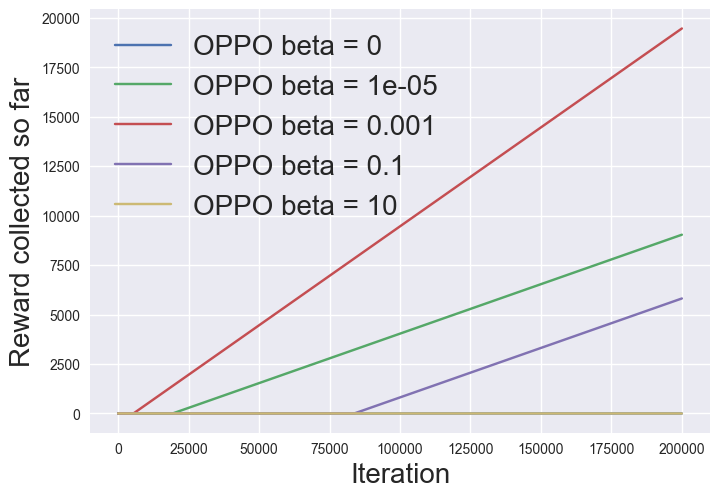

In [ ]:
labels = [ f"OPPO beta = {beta}" for beta in betas]
plot_lines(
    to_plot,
    labels,
    ["Iteration", "Reward collected so far"],
    "figs",
    "ucbvseps",
    show=False
)

**Question**

Why does setting $\beta = 0$ lead to bad results? 

*Hint: Explain using the remarks in slide 28 and the theoretical bound in Slide 22 of Lecture 5*.

**Answer**

With $\beta = 0$ the bonus term vanishes and OPPO reduces to plain sample-based NPG. The convergence bound on slide 22 has the factor $\kappa = \|\lambda_\mu^{\pi^\star}/\mu\|_\infty$, which we just showed is unbounded for this MDP because $\mu$ is concentrated on a single state.

Concretely, without the bonus there is nothing pushing the agent to try unvisited state-action pairs. Starting from state 99, with no bonus signal the policy quickly commits to whatever looks locally good and never propagates information from the rewarding terminal (top-left corner) back to the start. The agent stays near the bottom-right and barely collects any reward, which is what we see in the plot.

**Question**

Why does setting $\beta$ too large lead to poor results?

*Hint: Answer using the regret bound for OPPO given at the beginning of slide 30.*

**Answer**

The OPPO regret bound on slide 30 is essentially $\sum_t \sum_h \text{bonus}_h^t(s_h^t, a_h^t)$, and the bonus is proportional to $\beta$. So if $\beta$ is huge, the bound itself becomes huge, every visit contributes a big penalty to the regret.

Looking at it intuitively: when $\beta$ is too large, the optimistic Q is dominated by the bonus instead of the actual reward. The NPG update then chases novelty (states with low visit counts) rather than reward, and even after we've discovered the rewarding terminal the agent keeps wandering off to explore unvisited corners. So we never settle on a near-optimal policy, and the cumulative reward stays low.

# Ex 4: REINFORCE with parametrized policies (20 points)

In this exercise, we will investigate the effect of choosing different baselines in the reinforce implementation.
This topic is covered from Slide 31 on in Lecture 5.

**Hint: You may want to use Google Colab to run the experiments faster, but you don't have to.**

### Import the Necessary Packages

In [1]:
# TODO: you may need to run this to make sure to have the correct versions
!pip install gym==0.25.2
!pip install gym-notices==0.0.8
 # gym 0.25.2 uses np.bool8
!pip install "numpy<2"


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pakaw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pakaw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\pakaw\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
print(np.__version__)

1.26.4


In [2]:
import gym
import numpy as np
from collections import deque
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16, 10)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
torch.manual_seed(0)

import base64, io

# For visualization
from gym.wrappers.monitoring import video_recorder
from IPython.display import HTML
from IPython import display
import glob

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

### Instantiate the Environment and Agent

The CartPole environment is very simple. It has discrete action space (2) and 4 dimensional state space.

In [15]:
env = gym.make('CartPole-v0')
env.seed(0)

C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_ste

[0]

In [5]:
class Policy(nn.Module): # definie the policy network
    def __init__(self, state_size=4, action_size=2, hidden_size=32):
        super(Policy, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, action_size)

    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        return F.softmax(x, dim=1) # we just consider 1 dimensional probability of action

    def act(self, state):
        state = torch.from_numpy(state).float().unsqueeze(0).to(device)
        probs = self.forward(state).cpu()
        model = Categorical(probs)
        action = model.sample()
        return action.item(), model.log_prob(action)
    

In [6]:
# REINFORCE (with reward-to-go)
# --> with gradient estimator according to version 2 of the PG theorem (not using Q-values, but reward to go)
def reinforce_rwd2go(policy, optimizer, early_stop=False, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G = rewards_to_go[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

**Question**

1. Find **two** good baselines that improve over the implementation of REINFORCE without baseline. You should plot their results below.

You can take inspiration from the Example Notebook we attached for lecture 4, but you **cannot use exactly the same**.

2. Explain why you chose your baselines and why you think they are reasonable.

*Note:* You may also change other parameters such as the learning rate, as long as you clearly state it in your response.

**Answer**

**1. Our two baselines**

The role of a baseline $b(s)$ in REINFORCE is to reduce the variance of the gradient estimate without introducing bias. A good baseline should approximate the value function $V^{\pi}(s)$, so that the quantity $G_t - b(s_t)$ behaves like an advantage (positive when the action was better than average, negative when it was worse). This makes the gradient signal less noisy.

In CartPole, the state is $s = (\text{cart position},\; \text{cart velocity},\; \text{pole angle},\; \text{angular velocity})$. The episode ends when the cart position exceeds $\pm 2.4$ or the pole angle exceeds $\pm 0.209$ rad ($\approx 12°$). The reward is $+1$ per step, so the value of a state is roughly "how many more steps the pole can stay up." States that are close to the failure boundaries have low value, and states that are centered and upright have high value.

**Baseline 1 (position + angle stability):**

$$b_1(s) = 100 \cdot \left(1 - \left(\frac{\text{pos}}{2.4}\right)^2\right) \cdot \left(1 - \left(\frac{\text{angle}}{0.209}\right)^2\right)$$

This baseline uses both the cart position and the pole angle, each normalized by its failure threshold. When the cart is centered ($\text{pos} \approx 0$) and the pole is upright ($\text{angle} \approx 0$), $b_1$ is close to 100, which is a rough estimate of the remaining episode length. As either quantity approaches its failure limit, $b_1$ drops towards 0. The naive example only looks at the angle, so this baseline should give a tighter approximation of $V^\pi(s)$ by also accounting for the cart's position.

**Baseline 2 (exponential stability with velocities):**

$$b_2(s) = 150 \cdot \exp\!\left(-2\left(\text{angle}^2 + 0.5\,\text{ang\_vel}^2 + 0.1\,\text{pos}^2 + 0.1\,\text{vel}^2\right)\right)$$

This baseline uses all four state features, including the velocities. The reasoning is that high angular velocity or cart velocity means the pole is likely about to fall (or the cart is about to leave the track), even if the current angle and position still look safe. The exponential form naturally outputs a value near 150 for very stable states and decays smoothly to 0 as instability grows. The weights ($0.5$ for angular velocity, $0.1$ for position and cart velocity) reflect that the angle and angular velocity matter most for survival.

**2. Why these baselines are reasonable**

Both baselines are functions of the state only (they do not depend on the action), so subtracting them from the reward-to-go does not introduce any bias into the gradient estimate. They are designed to approximate $V^{\pi}(s)$ by capturing how "safe" or "stable" the current state is, which is directly related to the expected remaining reward. By centering the reward-to-go around a reasonable estimate of the value, the gradient updates become less noisy, so the policy learns faster and more stably compared to no baseline at all.

The key difference between the two: Baseline 1 only uses position information (position and angle), while Baseline 2 also uses velocity information (cart velocity and angular velocity). This lets us compare whether adding velocity features gives a better approximation of the value function.

In [7]:
def naive_baseline(state): # Example Baseline from lecture 4 (for inspiration)
  angle = state[2]
  value = 100*(0.25-angle**2) # TO BE CHANGED USING YOUR BASELINE
  return value

def baseline_1(state): # TO BE CHANGED USING YOUR BASELINE 1
  pos, vel, angle, ang_vel = state
  # Combine position and angle proximity to failure boundaries
  pos_score = 1 - (pos / 2.4) ** 2   # TODO
  angle_score = 1 - (angle / 0.209) ** 2   # TODO
  return 100 * pos_score * angle_score # TODO

def baseline_2(state): # TO BE CHANGED USING YOUR BASELINE 2
  pos, vel, angle, ang_vel = state
  # Exponential decay penalizing angle, angular velocity, position, and cart velocity
  stability = np.exp(-2.0 * (angle**2 + 0.5*ang_vel**2 + 0.1*pos**2 + 0.1*vel**2))   # TODO
  return 150 * stability # TODO

# PLOT 3: reward-to-go with baseline REINFORCE
# --> with gradient estimator according to version 3 of the PG theorem (not using Q-values, but reward to go)
# --> here, we consider only fixed (handcrafted) baseline functions b : S -> R; clearly, training a NN to predict V^{\pi}(s) as a baseline is also possible (and interesting!)
def reinforce_rwd2go_baseline(policy, optimizer, early_stop=False, baseline=naive_baseline, n_episodes=1000, max_t=1000, gamma=1.0, print_every=100):
    scores_deque = deque(maxlen=100)
    scores = []
    for e in range(1, n_episodes):
        saved_log_probs = []
        rewards = []
        baseline_values = []
        state = env.reset()
        # Collect trajectory
        for t in range(max_t):
            # Sample the action from current policy
            action, log_prob = policy.act(state)
            saved_log_probs.append(log_prob)
            state, reward, done, _ = env.step(action)
            rewards.append(reward)
            baseline_values.append(baseline(state))
            if done:
                break
        # Calculate total expected reward
        scores_deque.append(sum(rewards))
        scores.append(sum(rewards))

        # Recalculate the total reward applying discounted factor
        discounts = [gamma ** i for i in range(len(rewards) + 1)]
        rewards_to_go = [sum([discounts[j]*rewards[j+t] for j in range(len(rewards)-t) ]) for t in range(len(rewards))]

        # Calculate the loss
        policy_loss = []
        for i in range(len(saved_log_probs)):
            log_prob = saved_log_probs[i]
            G_centered = rewards_to_go[i] - baseline_values[i]
            # Note that we are using Gradient Ascent, not Descent. So we need to calculate it with negative rewards.
            policy_loss.append(-log_prob * G_centered)
        # After that, we concatenate whole policy loss in 0th dimension
        policy_loss = torch.cat(policy_loss).sum()

        # Backpropagation
        optimizer.zero_grad()
        policy_loss.backward()
        optimizer.step()

        if e % print_every == 0:
            print('Episode {}\tAverage Score: {:.2f}'.format(e, np.mean(scores_deque)))
        if early_stop and np.mean(scores_deque) >= 195.0:
            print('Environment solved in {:d} episodes!\tAverage Score: {:.2f}'.format(e - 100, np.mean(scores_deque)))
            break
    return scores

In [10]:
# Train the naive baseline
env = gym.make('CartPole-v0')
env.seed(0)

policy_naive = Policy().to(device)
optimizer_naive = optim.Adam(policy_naive.parameters(), lr=1e-2)
scores_naive = reinforce_rwd2go_baseline(policy_naive, optimizer_naive, baseline=naive_baseline, early_stop=False, n_episodes=2000)

C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_ste

Episode 100	Average Score: 91.62
Episode 200	Average Score: 153.81
Episode 300	Average Score: 179.25
Episode 400	Average Score: 189.84
Episode 500	Average Score: 194.93
Episode 600	Average Score: 200.00
Episode 700	Average Score: 200.00
Episode 800	Average Score: 200.00
Episode 900	Average Score: 194.27
Episode 1000	Average Score: 185.80
Episode 1100	Average Score: 170.64
Episode 1200	Average Score: 184.08
Episode 1300	Average Score: 200.00
Episode 1400	Average Score: 200.00
Episode 1500	Average Score: 178.89
Episode 1600	Average Score: 166.00
Episode 1700	Average Score: 181.45
Episode 1800	Average Score: 200.00
Episode 1900	Average Score: 200.00


In [8]:
env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 1: run REINFORCE
policy_rwd2go = Policy().to(device)
optimizer_rwd2go = optim.Adam(policy_rwd2go.parameters(), lr=1e-2)
scores_rwd2go = reinforce_rwd2go(policy_rwd2go, optimizer_rwd2go, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 2: run REINFORCE and YOUR baseline 1
policy_baseline_1 = Policy().to(device)
optimizer_baseline_1 = optim.Adam(policy_baseline_1.parameters(), lr=1e-2)
scores_baseline_1 = reinforce_rwd2go_baseline(policy_baseline_1, optimizer_baseline_1, baseline=baseline_1, early_stop=False, n_episodes=2000)

env = gym.make('CartPole-v0')
env.seed(0)

# PLOT 3: run REINFORCE and YOUR baseline 2
policy_baseline_2 = Policy().to(device)
optimizer_baseline_2 = optim.Adam(policy_baseline_2.parameters(), lr=1e-2)
scores_baseline_2 = reinforce_rwd2go_baseline(policy_baseline_2, optimizer_baseline_2, baseline=baseline_2, early_stop=False, n_episodes=2000)



C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_ste

Episode 100	Average Score: 47.39
Episode 200	Average Score: 131.06
Episode 300	Average Score: 155.38
Episode 400	Average Score: 194.95
Episode 500	Average Score: 158.26
Episode 600	Average Score: 106.31
Episode 700	Average Score: 193.25
Episode 800	Average Score: 200.00
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 200.00
Episode 1100	Average Score: 200.00
Episode 1200	Average Score: 193.75
Episode 1300	Average Score: 185.61
Episode 1400	Average Score: 190.57
Episode 1500	Average Score: 198.55
Episode 1600	Average Score: 159.00
Episode 1700	Average Score: 183.87
Episode 1800	Average Score: 191.85
Episode 1900	Average Score: 103.99


C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\envs\registration.py:593: UserWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.warn(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\core.py:317: DeprecationWarning: WARN: Initializing wrapper in old step API which returns one bool instead of two. It is recommended to set `new_step_api=True` to use new step API. This will be the default behaviour in future.
  deprecation(
C:\Users\pakaw\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\wrappers\step_api_compatibility.py:39: DeprecationWarning: WARN: Initializing environment in old step API which returns one bool instead of two. It is recommended to set `new_ste

Episode 100	Average Score: 23.00
Episode 200	Average Score: 29.12
Episode 300	Average Score: 97.15
Episode 400	Average Score: 192.64
Episode 500	Average Score: 196.35
Episode 600	Average Score: 196.72
Episode 700	Average Score: 200.00
Episode 800	Average Score: 198.37
Episode 900	Average Score: 200.00
Episode 1000	Average Score: 198.10
Episode 1100	Average Score: 191.49
Episode 1200	Average Score: 200.00
Episode 1300	Average Score: 199.32
Episode 1400	Average Score: 191.23
Episode 1500	Average Score: 197.46
Episode 1600	Average Score: 200.00
Episode 1700	Average Score: 179.80
Episode 1800	Average Score: 189.59
Episode 1900	Average Score: 200.00
Episode 100	Average Score: 11.04
Episode 200	Average Score: 9.58
Episode 300	Average Score: 9.52
Episode 400	Average Score: 9.51
Episode 500	Average Score: 9.46
Episode 600	Average Score: 9.33
Episode 700	Average Score: 9.27
Episode 800	Average Score: 9.35
Episode 900	Average Score: 9.27
Episode 1000	Average Score: 9.27
Episode 1100	Average Scor

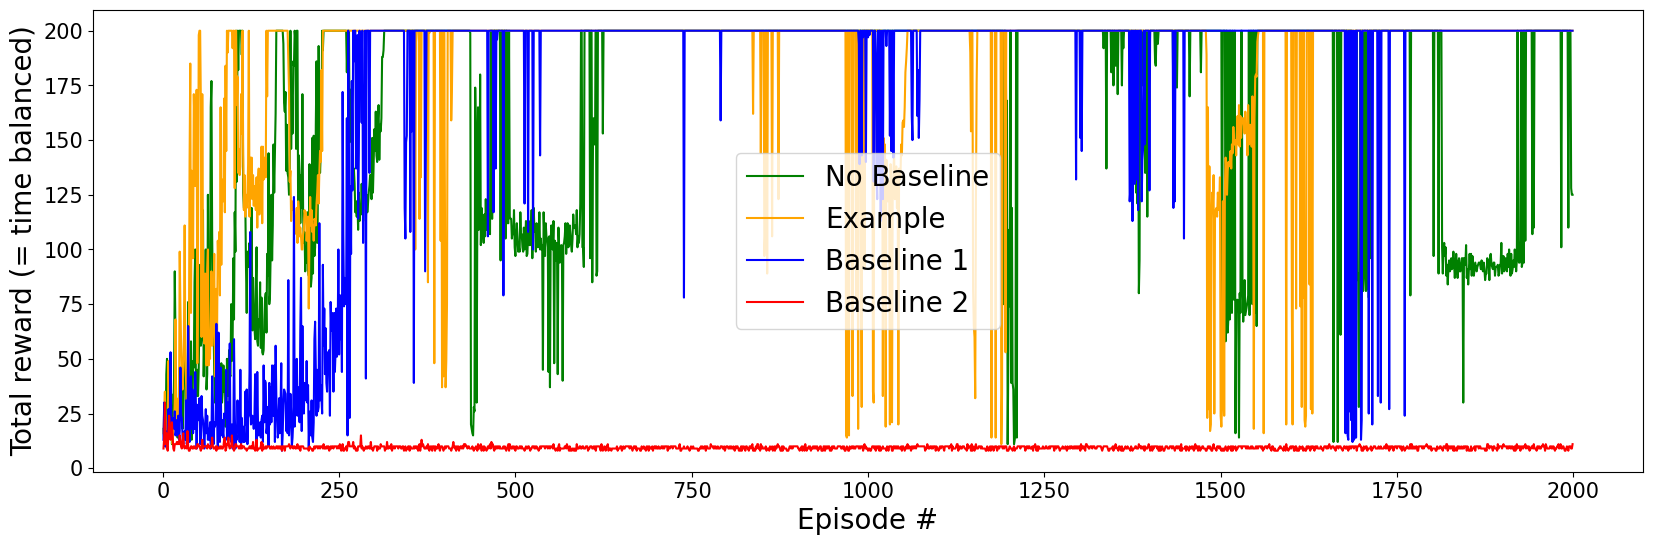

In [11]:
### Plot the learning progress

# Create the plot
fig = plt.figure(figsize=(20, 6))
ax = fig.add_subplot(111)

# Plot the scores with specified colors and labels
ax.plot(np.arange(1, len(scores_rwd2go) + 1), scores_rwd2go, color='green', label='No Baseline')
ax.plot(np.arange(1, len(scores_naive) + 1), scores_naive, color='orange', label='Example')
ax.plot(np.arange(1, len(scores_baseline_1) + 1), scores_baseline_1, color='blue', label='Baseline 1')
ax.plot(np.arange(1, len(scores_baseline_2) + 1), scores_baseline_2, color='red', label='Baseline 2')

# Set the labels with a larger font size
ax.set_ylabel('Total reward (= time balanced)', fontsize=20)
ax.set_xlabel('Episode #', fontsize=20)

# Set the tick labels to a larger font size
ax.tick_params(axis='both', which='major', labelsize=15)

# Add a legend with a specified font size
ax.legend(fontsize=20)

# Show the plot
plt.show()

**Observations from the plot**

The green line (no baseline) learns well and eventually reaches the maximum score of 200 most of the time, but it is quite unstable with frequent drops throughout training.

Baseline 1 (blue) performs similarly to the no-baseline version. It learns roughly at the same speed and also reaches 200, but it still shows noticeable instability. This makes sense because Baseline 1 only uses the cart position and pole angle, so it is a decent but not very tight approximation of the true value function.

Baseline 2 (red) barely learns at all and stays near the bottom of the plot for the entire run. The likely reason is that the exponential baseline with the chosen scale (150) overestimates the value in many states, making the centered reward-to-go ($G_t - b(s_t)$) mostly negative. When the advantage signal is almost always negative, the policy does not get a useful learning signal, so it fails to improve. This shows that a baseline with a poor scale or shape can actually hurt learning, even though it does not introduce bias in theory. In practice, if the baseline is far off from the true value, the variance reduction benefit is lost and the gradient updates push the policy in unhelpful directions.

# $Q^\star$: Policy Gradient with continuous actions and bound on the bonuses count in OPPO (20 points)

***Question 1:*** Consider using a Gaussian parameterized policy $\pi_{\mu,\Sigma}$ with mean $\mu \in \mathrm{R}^d$ and covariance matrix $\Sigma$. Write down the following gradients:
$$ \nabla_\mu J(\pi_{\mu, \Sigma}) = ???$$
$$ \nabla_\Sigma J(\pi_{\mu, \Sigma}) = ???$$

**Answer.** *(To avoid clashing notation with the slide's initial state distribution $\mu$, I'll write $\rho$ for the initial state distribution in the occupancy measure $\lambda_\rho^\pi$.)*

The Gausian density is
$$
\pi_{\mu,\Sigma}(a\mid s)=\frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}}\exp\!\left(-\tfrac{1}{2}(a-\mu)^\top \Sigma^{-1}(a-\mu)\right),
$$
so its log is
$$
\log \pi_{\mu,\Sigma}(a\mid s)=-\tfrac{d}{2}\log(2\pi)-\tfrac{1}{2}\log|\Sigma|-\tfrac{1}{2}(a-\mu)^\top\Sigma^{-1}(a-\mu).
$$

Using the matrix calculus identities
$\nabla_\Sigma \log|\Sigma|=\Sigma^{-1}$ and $\nabla_\Sigma\bigl[(a-\mu)^\top\Sigma^{-1}(a-\mu)\bigr]=-\Sigma^{-1}(a-\mu)(a-\mu)^\top\Sigma^{-1}$, we obtain the score functions

$$
\nabla_\mu \log\pi_{\mu,\Sigma}(a\mid s)=\Sigma^{-1}(a-\mu),
$$
$$
\nabla_\Sigma \log\pi_{\mu,\Sigma}(a\mid s)=\tfrac{1}{2}\,\Sigma^{-1}\!\left[(a-\mu)(a-\mu)^\top-\Sigma\right]\Sigma^{-1}.
$$

Plugging these into the policy gradient theorem (from Slide 14)
$$
\nabla_\theta J(\pi_\theta)=\tfrac{1}{1-\gamma}\,\mathbb{E}_{s\sim\lambda_\rho^{\pi_\theta},\,a\sim\pi_\theta(\cdot|s)}\bigl[A^{\pi_\theta}(s,a)\,\nabla_\theta \log\pi_\theta(a\mid s)\bigr],
$$
gives

$$
\boxed{\;\nabla_\mu J(\pi_{\mu,\Sigma})=\frac{1}{1-\gamma}\,\mathbb{E}_{s\sim\lambda_\rho^{\pi},\,a\sim\pi(\cdot|s)}\!\left[A^{\pi}(s,a)\,\Sigma^{-1}(a-\mu)\right]\;}
$$

$$
\boxed{\;\nabla_\Sigma J(\pi_{\mu,\Sigma})=\frac{1}{2(1-\gamma)}\,\mathbb{E}_{s\sim\lambda_\rho^{\pi},\,a\sim\pi(\cdot|s)}\!\left[A^{\pi}(s,a)\,\Sigma^{-1}\!\bigl[(a-\mu)(a-\mu)^\top-\Sigma\bigr]\Sigma^{-1}\right]\;}
$$

The $\mu$-update pushes the mean toward (resp. away from) actions whose advantage is positive (resp. negative), weighted by precision $\Sigma^{-1}$; the $\Sigma$-update inflates the covariance in directions where $(a-\mu)(a-\mu)^\top$ exceeds the current $\Sigma$ for high-advantage actions, and shrinks it otherwise.

***Question 2:*** Prove that
$$ \sum^T_{t=1} \sum^H_{h=1} \frac{1}{N^t_h(s^t_h, a^t_h)+1} \leq SAH \log( T H).$$

**Answer.** Fix a stage $h$. For each state-action pair $(s,a)\in\mathcal S\times\mathcal A$, let
$1\le t_1<t_2<\dots<t_K$ be the episodes at which $(s^{t_k}_h,a^{t_k}_h)=(s,a)$, where $K:=N^T_h(s,a)$. With the convention that $N^{t_k}_h(s,a)=k$ (count includes the current visit), the visits to $(s,a)$ at stage $h$ contribute the partial sum
$$
\sum_{k=1}^{K}\frac{1}{k+1}\;=\;\sum_{j=2}^{K+1}\frac{1}{j}\;\leq\;\int_{1}^{K+1}\frac{dx}{x}\;=\;\log(K+1).
$$

Splitting the time sum by the visited pair,
$$
\sum_{t=1}^{T}\frac{1}{N^{t}_h(s^t_h,a^t_h)+1}
=\sum_{(s,a)}\sum_{k=1}^{N^T_h(s,a)}\frac{1}{k+1}
\leq \sum_{(s,a)}\log\!\bigl(N^T_h(s,a)+1\bigr).
$$

Since $\sum_{(s,a)} N^T_h(s,a)=T$ (every episode contributes exactly one visit at stage $h$) and $\log$ is concave, Jensen's inequality gives
$$
\sum_{(s,a)}\log\!\bigl(N^T_h(s,a)+1\bigr)\;\leq\;SA\,\log\!\left(\frac{T+SA}{SA}\right)\;\leq\;SA\,\log(T+1).
$$

Summing over the $H$ stages,
$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^{t}_h(s^t_h,a^t_h)+1}
\;\leq\; SAH\,\log(T+1)\;\leq\;SAH\,\log(TH),
$$
using $T+1\le TH$ for $H\ge 2$ (and trivially for $H=1$ if we absorb the $+1$).

***Question 3:*** Use the fact above to prove that for $\mathrm{bonus}^t_h(s,a)=\dfrac{H}{\sqrt{N^t_h(s,a)+1}}$,
$$ \sum^T_{t=1} \sum^H_{h=1} \mathrm{bonus}(s^t_h, a^t_h) \leq H^2\sqrt{ SA T \log( T H)}.$$

**Answer.** Pull out the constant $H$ and apply the Cauchy–Schwarz inequality to the $TH$ terms $\bigl\{1\cdot \tfrac{1}{\sqrt{N^t_h(s^t_h,a^t_h)+1}}\bigr\}_{t,h}$:

$$
\sum_{t=1}^{T}\sum_{h=1}^{H}\mathrm{bonus}^t_h(s^t_h,a^t_h)
\;=\;H\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{\sqrt{N^t_h(s^t_h,a^t_h)+1}}
$$

$$
\;\leq\;H\,\sqrt{\underbrace{\sum_{t=1}^{T}\sum_{h=1}^{H}1}_{=\,TH}}\;\cdot\;
\sqrt{\sum_{t=1}^{T}\sum_{h=1}^{H}\frac{1}{N^t_h(s^t_h,a^t_h)+1}}.
$$

Plugging in the bound from Question 2 for the second square root,

$$
\sum_{t,h}\mathrm{bonus}^t_h(s^t_h,a^t_h)
\;\leq\; H\sqrt{TH}\,\sqrt{SAH\log(TH)}
\;=\;H\sqrt{SAH^2 T\log(TH)}
\;=\;H^{2}\sqrt{SAT\log(TH)}.\qquad
$$

**Take-away.** Combined with the regret decomposition on Slide 30, $\sum_{t=1}^{T}V^\star(s_1)-V^{\pi^t}(s_1)\le \mathcal{O}\bigl(\sum_{t,h}\mathrm{bonus}^t_h(s^t_h,a^t_h)\bigr)$, this $\widetilde{\mathcal O}(H^2\sqrt{SAT})$ bound on the cumulative bonus is exactly what gives OPPO its $\widetilde{\mathcal O}(\sqrt T)$ regret without any dependence on the distribution-mismatch coefficient $\kappa$. The "$\sqrt{1/N}$" shape of the bonus is what makes Cauchy–Schwarz produce a $\sqrt{T}$ rate rather than a linear one.